# Description des variables du dataset de résultats

Ce dataset contient l’historique des différentes exécutions d’entraînement du modèle YOLO de segmentation.  
Chaque ligne représente une exécution complète avec ses métriques de performance.

## Comprendre les métriques mAP

Le **mAP** (*mean Average Precision*) est une métrique utilisée pour évaluer la qualité d’un modèle de détection ou de segmentation.

Elle mesure la capacité du modèle à :

- détecter correctement les objets
- bien localiser leur position
- bien segmenter leurs contours

Une valeur plus proche de **1.0** indique une meilleure performance.

### mAP50

Le **mAP50** utilise un seuil de **IoU = 0.50** (*Intersection over Union*).

Cela signifie qu’une prédiction est considérée correcte si elle recouvre au moins **50%** de la vérité terrain (*ground truth*).

C’est une métrique plus tolérante.

---

### mAP50-95

Le **mAP50-95** est plus strict.

Il calcule la moyenne du mAP sur plusieurs seuils IoU :

- 0.50
- 0.55
- 0.60
- ...
- 0.95

Cette métrique donne une évaluation plus complète et plus robuste du modèle.

---

## Variables

### `sample_size`

Nombre d’images utilisées pour l’entraînement (*training set*).

Exemple :

- `500` → expérience réduite
- `4986` → dataset complet

Cette variable est essentielle pour comparer les performances selon la taille du dataset.

---
### `epochs`

Nombre total d’itérations complètes sur le dataset.

Un epoch correspond à un passage complet sur toutes les images d’entraînement.

Plus le nombre d’epochs est élevé :

- plus le modèle apprend
- mais le risque de *overfitting* augmente

---

### `best_box_map50`

Meilleure valeur de **mAP50** pour la détection des boîtes (*bounding boxes*).

Mesure la qualité de localisation des objets avec un seuil IoU de 50%.

Plus la valeur est proche de 1, meilleure est la performance.

---

### `best_box_map50_95`

Meilleure valeur de **mAP50-95** pour les boîtes.

Cette métrique est plus stricte et plus représentative de la robustesse globale du modèle.

---

### `best_mask_map50`

Meilleure valeur de **mAP50** pour la segmentation (*masks*).

C’est la métrique principale du projet.

Elle mesure la précision du contour segmenté des objets.

Plus cette valeur est élevée, meilleure est la segmentation.

---

### `best_mask_map50_95`

Meilleure valeur de **mAP50-95** pour les masques.

Version plus stricte de la métrique précédente.

Permet d’évaluer la qualité globale de segmentation sur plusieurs niveaux de précision.

In [14]:
import pandas as pd
import glob
import matplotlib.pyplot as plt

files = glob.glob("runnings/all_runs_metrics_*.csv")

dfs = []
for f in files:
    df = pd.read_csv(f)
    df["source_file"] = f
    dfs.append(df)

df = pd.concat(dfs, ignore_index=True)

df

,timestamp,seed,sample_size,val_size,epochs,best_box_map50,best_box_map50_95,best_mask_map50,best_mask_map50_95,promoted,source_file
0,2026-06-26T02:07:55.150140,378229,500,214,50,0.09747,0.07430,0.09655,0.07255,True,runnings\all_runs_metrics_26.csv
1,2026-06-26T02:26:11.818530,973184,500,214,50,0.10409,0.08119,0.10319,0.07669,True,runnings\all_runs_metrics_27.csv
2,2026-06-26T02:46:45.537974,109300,500,214,50,0.10931,0.08691,0.10907,0.08432,True,runnings\all_runs_metrics_28.csv
3,2026-06-26T03:07:06.236827,828650,500,214,50,0.10581,0.08569,0.10464,0.08431,True,runnings\all_runs_metrics_29.csv
4,2026-06-26T03:27:14.940150,924436,500,214,50,0.11113,0.08947,0.11319,0.08531,True,runnings\all_runs_metrics_30.csv
5,2026-06-26T03:48:03.733084,792524,500,214,50,0.10559,0.08355,0.10801,0.08383,True,runnings\all_runs_metrics_31.csv
6,2026-06-26T04:07:27.669705,408280,500,214,50,0.09738,0.07825,0.09890,0.07407,True,runnings\all_runs_metrics_32.csv
7,2026-06-26T04:26:56.493146,466490,500,214,50,0.10415,0.08439,0.10142,0.07960,True,runnings\all_runs_metrics_33.csv
8,2026-06-26T04:46:42.051293,712086,500,214,50,0.09185,0.07233,0.09300,0.07023,True,runnings\all_runs_metrics_34.csv
9,2026-06-26T05:06:35.563315,692560,500,214,50,0.11701,0.09179,0.11587,0.08620,True,runnings\all_runs_metrics_35.csv


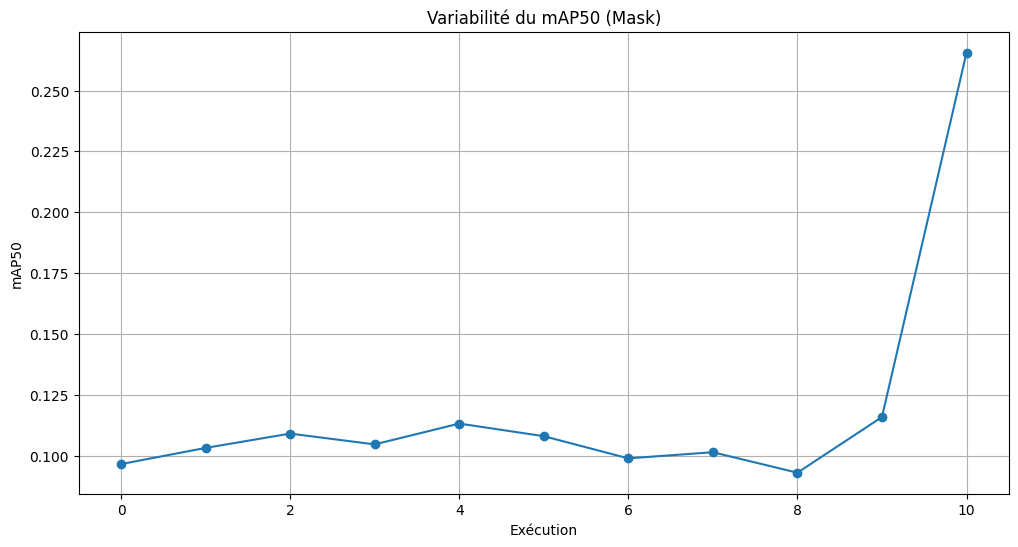

In [15]:
plt.figure(figsize=(12,6))
plt.plot(df.index, df["best_mask_map50"], marker="o")
plt.title("Variabilité du mAP50 (Mask)")
plt.xlabel("Exécution")
plt.ylabel("mAP50")
plt.grid(True)
plt.show()

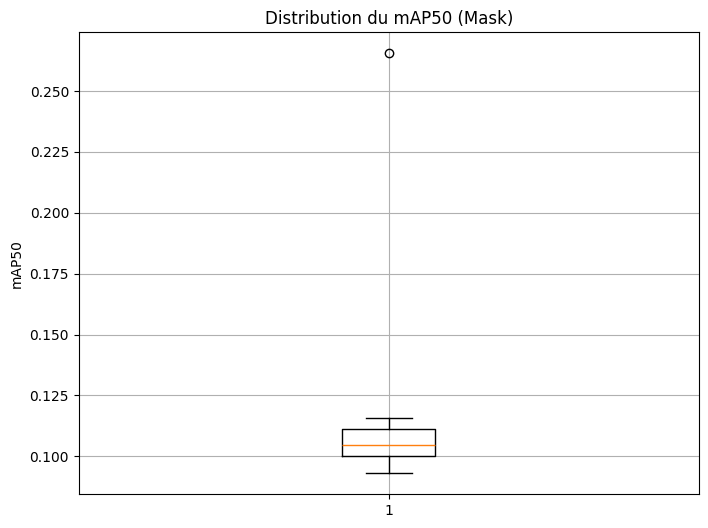

In [16]:
plt.figure(figsize=(8,6))
plt.boxplot(df["best_mask_map50"])
plt.title("Distribution du mAP50 (Mask)")
plt.ylabel("mAP50")
plt.grid(True)
plt.show()

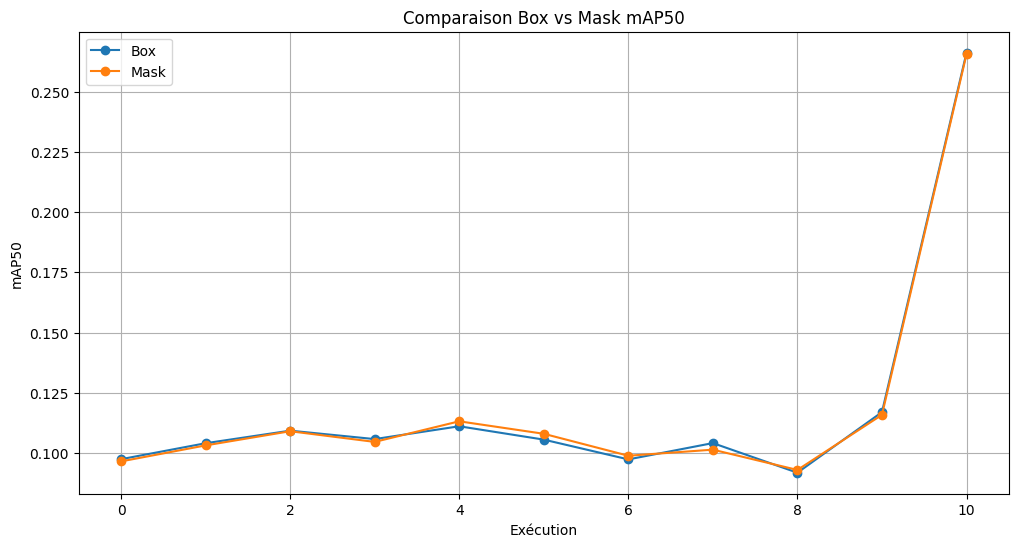

In [17]:
plt.figure(figsize=(12,6))
plt.plot(df.index, df["best_box_map50"], marker="o", label="Box")
plt.plot(df.index, df["best_mask_map50"], marker="o", label="Mask")
plt.title("Comparaison Box vs Mask mAP50")
plt.xlabel("Exécution")
plt.ylabel("mAP50")
plt.legend()
plt.grid(True)
plt.show()

In [18]:
print("Mean mAP50 Mask:", df["best_mask_map50"].mean())
print("Std mAP50 Mask:", df["best_mask_map50"].std())
print("Min mAP50 Mask:", df["best_mask_map50"].min())
print("Max mAP50 Mask:", df["best_mask_map50"].max())
print("Amplitude:", df["best_mask_map50"].max() - df["best_mask_map50"].min())

Mean mAP50 Mask: 0.11903272727272726
Std mAP50 Mask: 0.049071652935459405
Min mAP50 Mask: 0.093
Max mAP50 Mask: 0.26552
Amplitude: 0.17251999999999998
